In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

label_encoder = LabelEncoder()

data_path = '/Users/divijakejriwal/Desktop/project 1/data.csv'

In [3]:
df = pd.read_csv(data_path, low_memory=False)
df_original = df

In [4]:
df.shape

(855969, 73)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 855969 entries, 0 to 855968
Data columns (total 73 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           855969 non-null  int64  
 1   member_id                    855969 non-null  int64  
 2   loan_amnt                    855969 non-null  int64  
 3   funded_amnt                  855969 non-null  int64  
 4   funded_amnt_inv              855969 non-null  float64
 5   term                         855969 non-null  object 
 6   int_rate                     855969 non-null  float64
 7   installment                  855969 non-null  float64
 8   grade                        855969 non-null  object 
 9   sub_grade                    855969 non-null  object 
 10  emp_title                    806526 non-null  object 
 11  emp_length                   812908 non-null  object 
 12  home_ownership               855969 non-null  object 
 13 

In [6]:
df_original.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'pymnt_plan', 'desc', 'purpose', 'title', 'zip_code',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'verification_status_joint', 'acc_now_delinq', 'tot_col

In [7]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,default_ind
0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [8]:
df.describe()
#Initial list status - Fractional or whole amount by an investor

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,...,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,default_ind
count,8.559690e+05,8.559690e+05,855969.000000,855969.000000,855969.000000,855969.000000,855969.000000,8.559690e+05,855969.000000,855969.000000,...,11609.000000,13288.000000,13288.000000,13288.000000,13288.000000,7.886560e+05,13288.000000,13288.000000,13288.000000,855969.000000
mean,3.224073e+07,3.476269e+07,14745.571335,14732.378305,14700.061226,13.192320,436.238072,7.507119e+04,18.122165,0.311621,...,71.486993,1.354305,2.945515,5840.443332,61.024526,3.216357e+04,0.947772,1.524232,1.841963,0.054286
std,2.271969e+07,2.399418e+07,8425.340005,8419.471653,8425.805478,4.368365,243.726876,6.426447e+04,17.423629,0.857189,...,23.015293,1.483710,2.595313,5108.500262,20.018117,3.769964e+04,1.441667,2.697601,2.975049,0.226581
min,5.473400e+04,7.069900e+04,500.000000,500.000000,0.000000,5.320000,15.690000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,-4.000000,0.000000
25%,9.067986e+06,1.079273e+07,8000.000000,8000.000000,8000.000000,9.990000,260.550000,4.500000e+04,11.880000,0.000000,...,58.500000,0.000000,1.000000,2405.000000,47.900000,1.400000e+04,0.000000,0.000000,0.000000,0.000000
50%,3.431355e+07,3.697532e+07,13000.000000,13000.000000,13000.000000,12.990000,382.550000,6.500000e+04,17.610000,0.000000,...,75.000000,1.000000,2.000000,4485.500000,62.100000,2.380000e+04,0.000000,0.000000,2.000000,0.000000
75%,5.446311e+07,5.803559e+07,20000.000000,20000.000000,20000.000000,15.990000,571.560000,9.000000e+04,23.900000,0.000000,...,87.500000,2.000000,4.000000,7701.250000,75.300000,3.990000e+04,1.000000,2.000000,3.000000,0.000000
max,6.861687e+07,7.351969e+07,35000.000000,35000.000000,35000.000000,28.990000,1445.460000,9.500000e+06,9999.000000,39.000000,...,223.300000,22.000000,43.000000,83047.000000,151.400000,9.999999e+06,15.000000,33.000000,32.000000,1.000000


Data Cleaning

In [10]:
missing_values = df.isnull().sum()
print("Missing values count = ",(missing_values))

Missing values count =  id                       0
member_id                0
loan_amnt                0
funded_amnt              0
funded_amnt_inv          0
                     ...  
total_rev_hi_lim     67313
inq_fi              842681
total_cu_tl         842681
inq_last_12m        842681
default_ind              0
Length: 73, dtype: int64


In [11]:
# drop columns where more than 80% of values are null
threshold = 0.8
df_cleaned = df.dropna(thresh=int((1 - threshold) * len(df)), axis=1)
df_cleaned.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default_ind
0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,...,01-01-2016,0.0,NaN,1,INDIVIDUAL,0,NaN,NaN,NaN,0
1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,...,01-09-2013,0.0,NaN,1,INDIVIDUAL,0,NaN,NaN,NaN,1
2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,...,01-01-2016,0.0,NaN,1,INDIVIDUAL,0,NaN,NaN,NaN,0
3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,...,01-01-2015,0.0,NaN,1,INDIVIDUAL,0,NaN,NaN,NaN,0
4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,...,01-01-2016,0.0,NaN,1,INDIVIDUAL,0,NaN,NaN,NaN,0


In [12]:
df_cleaned.isnull().sum()

id                                  0
member_id                           0
loan_amnt                           0
funded_amnt                         0
funded_amnt_inv                     0
term                                0
int_rate                            0
installment                         0
grade                               0
sub_grade                           0
emp_title                       49443
emp_length                      43061
home_ownership                      0
annual_inc                          0
verification_status                 0
issue_d                             0
pymnt_plan                          0
purpose                             0
title                              34
zip_code                            0
addr_state                          0
dti                                 0
delinq_2yrs                         0
earliest_cr_line                    0
inq_last_6mths                      0
mths_since_last_delinq         439812
open_acc    

In [ ]:
df_cleaned = df_cleaned.dropna(subset=['tot_cur_bal'])
df_cleaned['mths_since_last_major_derog'].fillna(0, inplace=True)
df_cleaned['mths_since_last_delinq'].fillna(0, inplace=True)

In [ ]:
df_cleaned['emp_length'].fillna('Unknown', inplace=True)

In [ ]:
df_cleaned['next_pymnt_date'] = pd.to_datetime(df_cleaned['next_pymnt_d'], errors='coerce')
df_cleaned['next_pymnt_date'].fillna('ffill', inplace=True)

In [ ]:
df_cleaned['last_pymnt_date'] = pd.to_datetime(df_cleaned['last_pymnt_d'], errors='coerce')
df_cleaned['last_pymnt_date'].fillna('ffill', inplace=True)
df_cleaned['last_credit_pull_date'] = pd.to_datetime(df_cleaned['last_credit_pull_d'], errors='coerce')
df_cleaned['last_credit_pull_date'].fillna('ffill', inplace=True)

In [17]:
# Issue date - years
df['issue_date'] = pd.to_datetime(df['issue_d'], errors='coerce')
df['issue_year'] = df['issue_date'].dt.year

In [18]:
df_cleaned.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default_ind,next_pymnt_date,last_pymnt_date,last_credit_pull_date
39694,10149342,12000897,27050,27050,27050.0,36 months,10.99,885.46,B,B2,...,1,INDIVIDUAL,0,0.0,114834.0,59900.0,0,2016-01-02 00:00:00,2016-01-01 00:00:00,2015-01-12 00:00:00
39695,10159584,12011200,9750,9750,9750.0,36 months,13.98,333.14,C,C1,...,1,INDIVIDUAL,0,0.0,14123.0,15100.0,0,2016-01-02 00:00:00,2016-01-01 00:00:00,2016-01-01 00:00:00
39696,10159498,1319523,12000,12000,12000.0,36 months,6.62,368.45,A,A2,...,1,INDIVIDUAL,0,0.0,267646.0,61100.0,0,2016-01-02 00:00:00,2016-01-01 00:00:00,2016-01-01 00:00:00
39697,10139658,11991209,12000,12000,12000.0,36 months,13.53,407.40,B,B5,...,1,INDIVIDUAL,0,15386.0,13605.0,8100.0,0,ffill,2015-01-09 00:00:00,2016-01-01 00:00:00
39698,10159548,12011167,15000,15000,15000.0,36 months,8.90,476.30,A,A5,...,1,INDIVIDUAL,0,1514.0,272492.0,15400.0,0,2016-01-02 00:00:00,2016-01-01 00:00:00,2016-01-01 00:00:00


In [19]:
# dropping unecessary columns
df_cleaned.drop(['id', 'emp_title', 'zip_code', 'title', 'next_pymnt_d', 'last_pymnt_d', 'last_credit_pull_d', 'issue_d'], axis=1, inplace=True)

In [20]:
df_cleaned.isnull().sum()
# revol_util                     366
# last_credit_pull_d              48

member_id                        0
loan_amnt                        0
funded_amnt                      0
funded_amnt_inv                  0
term                             0
int_rate                         0
installment                      0
grade                            0
sub_grade                        0
emp_length                       0
home_ownership                   0
annual_inc                       0
verification_status              0
pymnt_plan                       0
purpose                          0
addr_state                       0
dti                              0
delinq_2yrs                      0
earliest_cr_line                 0
inq_last_6mths                   0
mths_since_last_delinq           0
open_acc                         0
pub_rec                          0
revol_bal                        0
revol_util                     366
total_acc                        0
initial_list_status              0
out_prncp                        0
out_prncp_inv       

In [21]:
df = df_cleaned

In [22]:
df.shape

(788656, 49)

Exploratory Data Analysis (EDA)

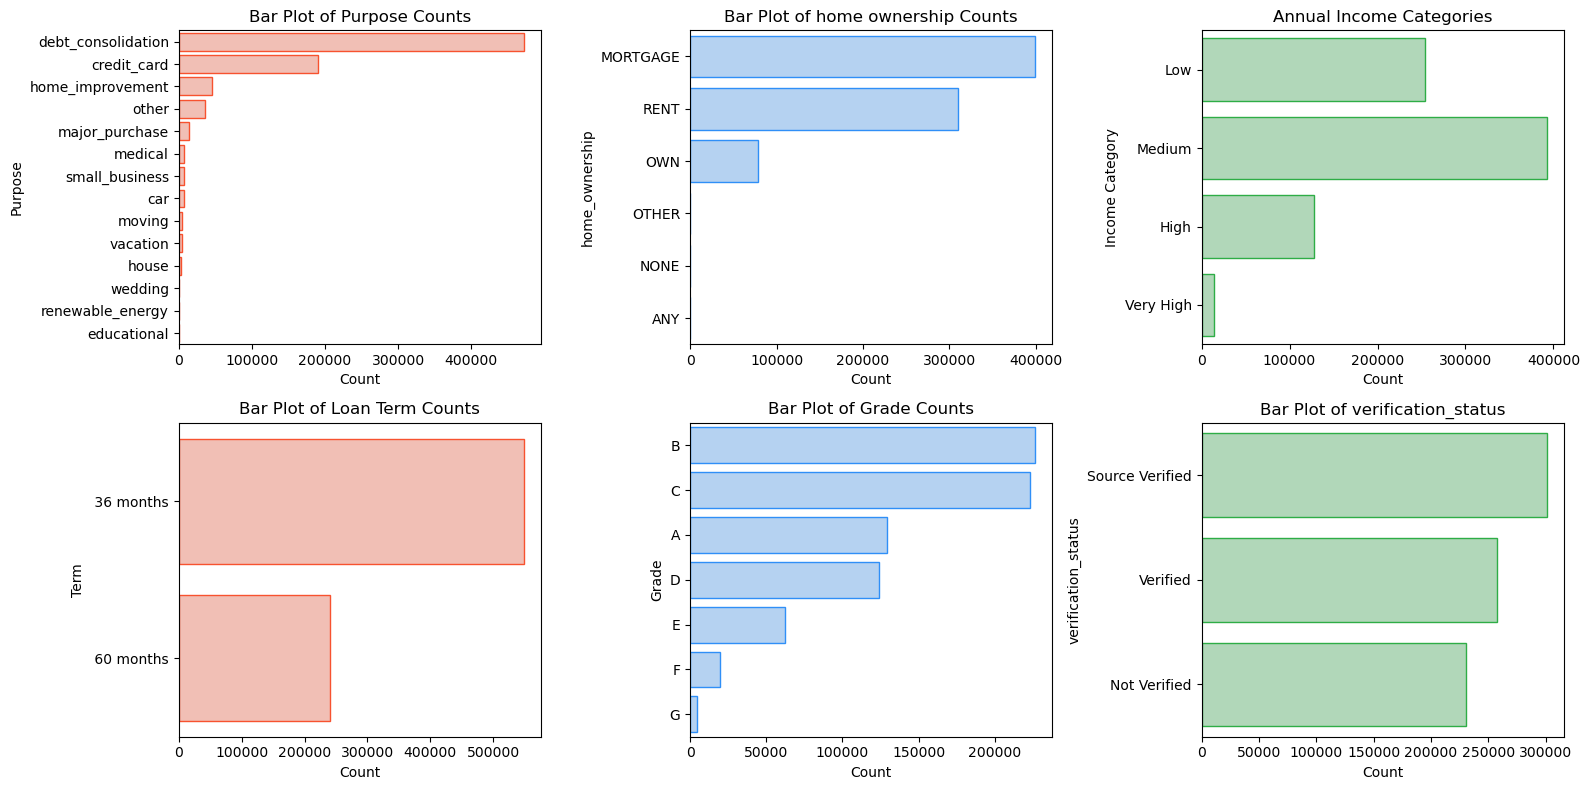

In [24]:
colours = ['#fbb9ab', '#abd2fb', '#aadeb5']
edgecolours = ['#F7522F', '#2F8FF7', '#2EAD46']

columns = ['purpose', 'home_ownership', 'term']
plt.figure(figsize=(16,8))

plt.subplot(2,3,1)

unique_values = df['purpose'].value_counts()

sns.barplot(x=unique_values, y=unique_values.index, color=colours[0], edgecolor=edgecolours[0])

plt.xlabel('Count')
plt.ylabel('Purpose')
plt.title('Bar Plot of Purpose Counts')

plt.subplot(2,3,2)

unique_values = df['home_ownership'].value_counts()
sns.barplot(x=unique_values, y=unique_values.index, color=colours[1], edgecolor=edgecolours[1])

plt.xlabel('Count')
plt.ylabel('home_ownership')
plt.title('Bar Plot of home ownership Counts')

plt.subplot(2,3,3)
# Group incomes into categories
income_bins = pd.cut(df['annual_inc'], bins=[0, 50000, 100000, 200000, 500000], labels=['Low', 'Medium', 'High', 'Very High'])
sns.countplot(y=income_bins, color=colours[2], edgecolor=edgecolours[2])
plt.title('Annual Income Categories')
plt.xlabel('Count')
plt.ylabel('Income Category')

plt.subplot(2,3,4)

unique_values = df['term'].value_counts()
sns.barplot(x=unique_values, y=unique_values.index, color=colours[0], edgecolor=edgecolours[0])

plt.xlabel('Count')
plt.ylabel('Term')
plt.title('Bar Plot of Loan Term Counts')

plt.subplot(2,3,5)
unique_values = df['grade'].value_counts()
sns.barplot(x=unique_values, y=unique_values.index, color=colours[1], edgecolor=edgecolours[1])

plt.xlabel('Count')
plt.ylabel('Grade')
plt.title('Bar Plot of Grade Counts')

plt.subplot(2,3,6)
unique_values = df['verification_status'].value_counts()
sns.barplot(x=unique_values, y=unique_values.index, color=colours[2], edgecolor=edgecolours[2])

plt.xlabel('Count')
plt.ylabel('verification_status')
plt.title('Bar Plot of verification_status')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

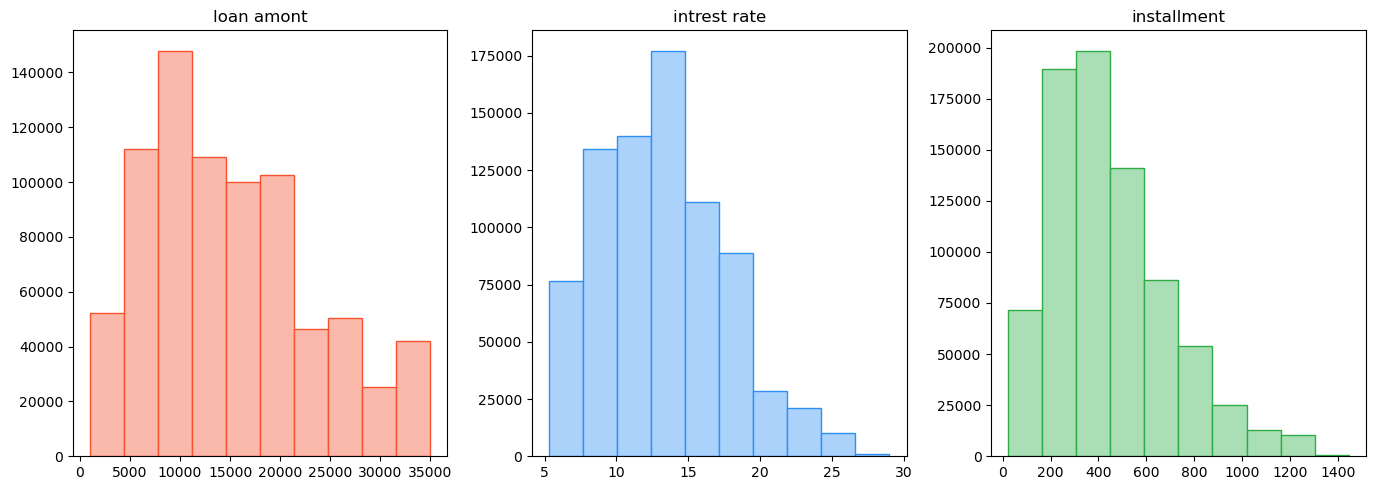

In [25]:
plt.figure(figsize=(14,5))

plt.subplot(1,3,1)

loan_amnt=df['loan_amnt']
plt.hist(loan_amnt, color='#fbb9ab', edgecolor='#F7522F')
plt.title('loan amont')

plt.subplot(1,3,2)

int_rate=df['int_rate']
plt.hist(int_rate, color='#abd2fb', edgecolor='#2F8FF7')
plt.title('intrest rate')

plt.subplot(1,3,3)

installment=df['installment']
plt.hist(installment, color='#aadeb5', edgecolor='#2EAD46')
plt.title('installment')
# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

/var/folders/m8/p9pngz193y1499l_pphwqmkh0000gn/T/ipykernel_75022/2261836335.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(loan_amount, ax=ax[0], color="#F7522F")
/var/folders/m8/p9pngz193y1499l_pphwqmkh0000gn/T/ipykernel_75022/2261836335.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(

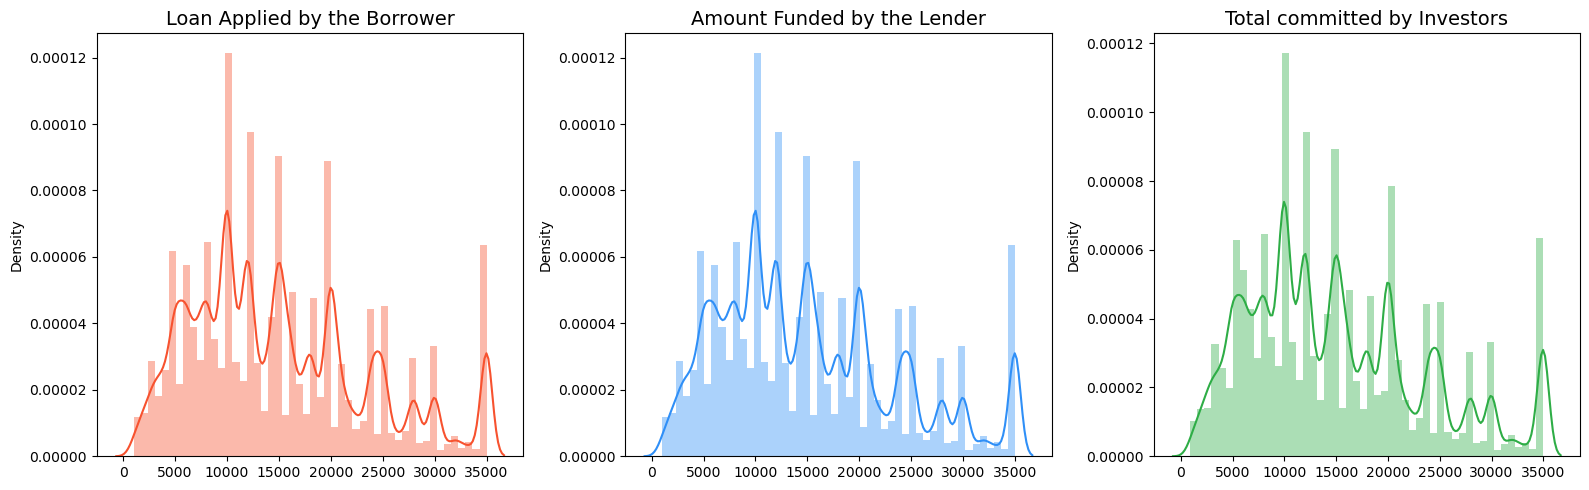

In [26]:
fig, ax = plt.subplots(1, 3, figsize=(16,5))

loan_amount = df["loan_amnt"].values
funded_amount = df["funded_amnt"].values
investor_funds = df["funded_amnt_inv"].values

sns.distplot(loan_amount, ax=ax[0], color="#F7522F")
ax[0].set_title("Loan Applied by the Borrower", fontsize=14)
sns.distplot(funded_amount, ax=ax[1], color="#2F8FF7")
ax[1].set_title("Amount Funded by the Lender", fontsize=14)
sns.distplot(investor_funds, ax=ax[2], color="#2EAD46")
ax[2].set_title("Total committed by Investors", fontsize=14)
plt.tight_layout()

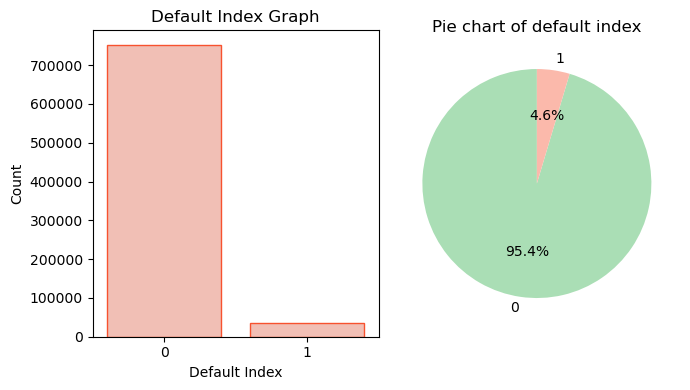

In [27]:
## Target Value - Default Index
plt.figure(figsize=(7,4))

plt.subplot(1,2,1)

sns.countplot(x=df['default_ind'], color='#fbb9ab', edgecolor='#F7522F')

plt.xlabel('Default Index')
plt.ylabel('Count')
plt.title('Default Index Graph')

plt.subplot(1,2,2)

colours = ['#aadeb5', '#fbb9ab']
data = df['default_ind'].value_counts()
plt.pie(data, labels=data.index, autopct='%1.1f%%', startangle=90, colors=colours)
plt.title('Pie chart of default index')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

Handling categorical features

Label Encoding: This assigns a unique integer to each category. This can be risky if the model interprets the categories as having an ordinal relationship when there isn't one. It's typically used for tree-based models like Random Forests or XGBoost, which don't assume an ordinal relationship in the encoded integers.

One-Hot Encoding if the number of categories is relatively small (not too many columns will be added). If there are many categories or high-cardinality features, consider alternatives like Target Encoding or Frequency Encoding.

In [ ]:
# Ordinal Number Encoding
grade_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade_ordinal'] = df['grade'].map(grade_mapping)

initial_status_mapping = {'f': 1, 'w': 0}
df['initial_list_status'] = df['initial_list_status'].map(initial_status_mapping)

print(len(df['sub_grade'].value_counts().unique()))
# As each sub_grade has different frequency and there are 35 sub_grades we use Count or Frequency Encoding
subgrade_mapping=df['sub_grade'].value_counts().to_dict()
df['sub_grade']=df['sub_grade'].map(subgrade_mapping)

# Ordinal Number Encoding
df['term_months'] = df['term'].str.extract("(\d+)").astype(int)

subgrade_mapping=df['addr_state'].value_counts().to_dict()
df['addr_state']=df['addr_state'].map(subgrade_mapping)

df['verification_status_encoded'] = label_encoder.fit_transform(df['verification_status'])

In [30]:
categorical_df = df.select_dtypes(include=['object'])
categorical_df.columns

Index(['term', 'grade', 'emp_length', 'home_ownership', 'verification_status',
       'pymnt_plan', 'purpose', 'earliest_cr_line', 'application_type',
       'next_pymnt_date', 'last_pymnt_date', 'last_credit_pull_date'],
      dtype='object')

In [31]:
df_encoded = pd.get_dummies(df, columns=['purpose', 'application_type', 'home_ownership', 'pymnt_plan', 'application_type'], drop_first=True)

In [32]:
df_encoded['emp_length'] = df_encoded['emp_length'].replace('Unknown', None)

In [33]:
# Employment lengths to be encoded
employment_lengths = ['< 1 year', '1 year', '2 years', '3 years', '4 years', 
                      '5 years', '6 years', '7 years', '8 years', '9 years', 
                      '10+ years']

# Initialize the LabelEncoder
label_encoder = LabelEncoder()
label_encoder.fit(employment_lengths) 
df_encoded['emp_length_encoded'] = df_encoded['emp_length'].apply(
    lambda x: label_encoder.transform([x])[0] if pd.notnull(x) else None
)
df_encoded['emp_length_encoded'].head()

39694    1.0
39695    0.0
39696    1.0
39697    1.0
39698    2.0
Name: emp_length_encoded, dtype: float64

In [34]:
df_encoded['emp_length_encoded'].isna().sum()

41040

In [35]:
categorical_cols = ['term', 'grade', 'verification_status', 'emp_length']
df = df_encoded.drop(columns=categorical_cols, errors='ignore')

In [36]:
df_encoded.shape

(788656, 70)

In [37]:
df.columns

Index(['member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
       'installment', 'sub_grade', 'annual_inc', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_amnt',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal',
       'total_rev_hi_lim', 'default_ind', 'next_pymnt_date', 'last_pymnt_date',
       'last_credit_pull_date', 'grade_ordinal', 'term_months',
       'verification_status_encoded', 'purpose_credit_card',
       'purpose_debt_consolidation', 'purpose_educational',
       'purpose_home_improvement', 'purpose_house', 'purpo

In [38]:
current_date = pd.to_datetime('today')

# Convert the date columns to datetime
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], errors='coerce')
df['last_pymnt_date'] = pd.to_datetime(df['last_pymnt_date'], errors='coerce')
df['last_credit_pull_date'] = pd.to_datetime(df['last_credit_pull_date'], errors='coerce')

# Derive new features from date columns
df['credit_history_length'] = (current_date - df['earliest_cr_line']).dt.days // 365  # Years of credit history
df['months_since_last_pymnt'] = (current_date - df['last_pymnt_date']).dt.days // 30  # Months since last payment
df['months_since_credit_pull'] = (current_date - df['last_credit_pull_date']).dt.days // 30  # Months since last credit pull

df['months_since_last_pymnt'] = df['months_since_last_pymnt'].fillna(0)
df['months_since_credit_pull'] = df['months_since_credit_pull'].fillna(0)

# Drop the original date columns if no longer needed
df.drop(columns=['earliest_cr_line', 'next_pymnt_date', 'last_pymnt_date', 'last_credit_pull_date'], inplace=True)

In [39]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class CreditUtilizationRatioTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, include=True):
        self.revol_bal_col = 'revol_bal'
        self.annual_inc_col = 'annual_inc'
        self.installment_col = 'installment'
        self.total_rec_prncp_col = 'total_rec_prncp'
        self.funded_amnt_col = 'funded_amnt'

        self.include_rev_to_inc_ratio = include
        self.include_loan_to_inc_ratio = include
        self.include_repayment_progress = include


    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        # Find index of columns
        revol_bal_ix = np.where(X.columns == self.revol_bal_col)[0][0]
        annual_inc_ix = np.where(X.columns == self.annual_inc_col)[0][0]
        installment_ix = np.where(X.columns == self.installment_col)[0][0]
        total_rec_prncp_ix = np.where(X.columns == self.total_rec_prncp_col)[0][0]
        funded_amnt_ix = np.where(X.columns == self.funded_amnt_col)[0][0]

        # Calculate the Revolving Credit Balance to Annual Income Ratio.
        rev_to_inc_ratio = X.iloc[:, revol_bal_ix] / X.iloc[:, annual_inc_ix]

        # Calculate the Loan Payment-to-Income Ratio.
        loan_to_inc_ratio = X.iloc[:, installment_ix] / (X.iloc[:, annual_inc_ix] / 12)

        # Calculate the Repayment Progress.
        repayment_progress = (X.iloc[:, total_rec_prncp_ix] / X.iloc[:, funded_amnt_ix]) * 100

        if self.include_rev_to_inc_ratio:
            # Add the calculated Revolving Credit Balance to Annual Income Ratio as a new column to the input data.
            X['Rev_to_Inc_Ratio'] = rev_to_inc_ratio

        if self.include_loan_to_inc_ratio:
            # Add the calculated Loan Payment-to-Income Ratio as a new column to the input data.
            X['Loan_Payment_to_Income_Ratio'] = loan_to_inc_ratio

        if self.include_repayment_progress:
            # Add the calculated Repayment Progress as a new column to the input data.
            X['Repayment_Progress'] = repayment_progress

        return X

In [40]:
transformer = CreditUtilizationRatioTransformer(include=True)
df_transformed = transformer.fit_transform(df)

In [41]:
df = df_transformed

Handling Unbalanced Data using SMOTE and Dynamic under-sampling

In this section, we will see what is the amount of bad loans Lending Club has declared so far, of course we have to understand that there are still loans that are at a risk of defaulting in the future.
What we need to know:
The amount of bad loans could increment as the days pass by, since we still have a great amount of current loans.
Average annual income is an important key metric for finding possible opportunities of investments in a specific region.

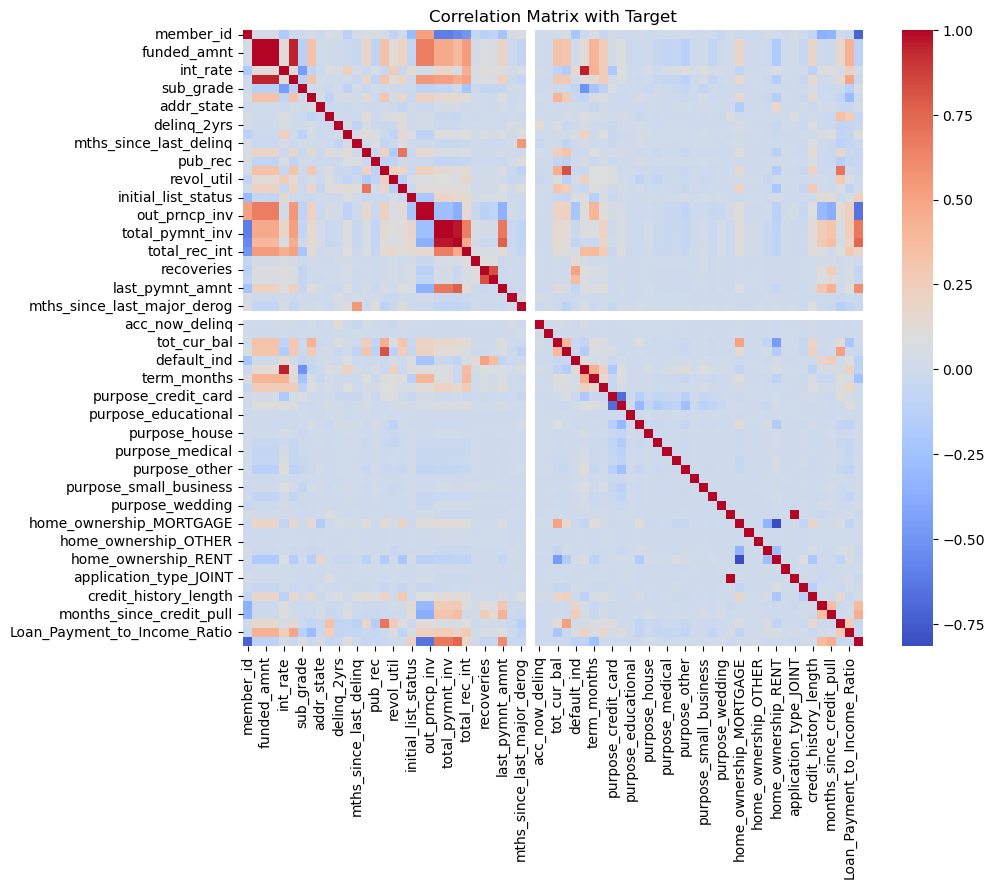

default_ind                 1.000000
recoveries                  0.496454
collection_recovery_fee     0.374254
months_since_credit_pull    0.254580
months_since_last_pymnt     0.194144
                              ...   
Repayment_Progress         -0.101608
member_id                  -0.209784
out_prncp                  -0.223300
out_prncp_inv              -0.223301
policy_code                      NaN
Name: default_ind, Length: 68, dtype: float64


In [44]:
numerical_df = df.select_dtypes(exclude=['object'])
# Calculate correlation with the target variable
correlation_matrix = numerical_df.corr()
correlations = correlation_matrix['default_ind'].sort_values(ascending=False)

# Plot the correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm")
plt.title("Correlation Matrix with Target")
plt.show()

# Display correlations with the target
print(correlations)


In [45]:
correlation_threshold = 0.04

# Filter the columns with correlations greater than the threshold
high_correlation_features = correlations[abs(correlations) > correlation_threshold]

In [46]:
high_correlation_features

default_ind                     1.000000
recoveries                      0.496454
collection_recovery_fee         0.374254
months_since_credit_pull        0.254580
months_since_last_pymnt         0.194144
int_rate                        0.161360
total_rec_late_fee              0.130997
grade_ordinal                   0.124346
initial_list_status             0.075365
inq_last_6mths                  0.069652
Loan_Payment_to_Income_Ratio    0.064867
total_rec_int                   0.043669
verification_status_encoded     0.043574
revol_util                      0.042099
sub_grade                      -0.070346
last_pymnt_amnt                -0.076357
total_rec_prncp                -0.080986
Repayment_Progress             -0.101608
member_id                      -0.209784
out_prncp                      -0.223300
out_prncp_inv                  -0.223301
Name: default_ind, dtype: float64

In [47]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify numerical and categorical columns in df
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Create a numerical imputer (replace NaN with mean)
numerical_imputer = SimpleImputer(strategy='mean')

# Create a categorical imputer (replace NaN with the most frequent value)
categorical_imputer = SimpleImputer(strategy='most_frequent')

# Create a column transformer to apply imputers to the respective columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_imputer, numerical_cols),   # Apply numerical imputer to numerical columns
        ('cat', categorical_imputer, categorical_cols) # Apply categorical imputer to categorical columns
    ])

# Apply the preprocessing pipeline
df_imputed = preprocessor.fit_transform(df)

# If you want to convert the result back to a DataFrame
df_imputed_df = pd.DataFrame(df_imputed, columns=numerical_cols.tolist() + categorical_cols.tolist())

# Now you can proceed with calculating mutual information or other analysis
print(df_imputed_df.head())


    member_id  loan_amnt  funded_amnt  funded_amnt_inv  int_rate  installment  \
0  12000897.0    27050.0      27050.0          27050.0     10.99       885.46   
1  12011200.0     9750.0       9750.0           9750.0     13.98       333.14   
2   1319523.0    12000.0      12000.0          12000.0      6.62       368.45   
3  11991209.0    12000.0      12000.0          12000.0     13.53       407.40   
4  12011167.0    15000.0      15000.0          15000.0      8.90       476.30   

   sub_grade  annual_inc  addr_state    dti  ...  grade_ordinal  term_months  \
0    43954.0     55000.0     20829.0  22.87  ...            2.0         36.0   
1    47598.0     26000.0    113253.0  25.12  ...            3.0         36.0   
2    19522.0    105000.0     11824.0  14.05  ...            1.0         36.0   
3    42831.0     40000.0      4439.0  16.94  ...            2.0         36.0   
4    39762.0     63000.0     53603.0  16.51  ...            1.0         36.0   

   verification_status_encoded  

In [48]:
df = df_imputed_df

In [49]:
from sklearn.feature_selection import mutual_info_classif

# Separate features and target
X = df.drop(columns=['default_ind'])
y = df['default_ind']

# Calculate mutual information
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Display top mutual information scores
print(mi_series.head(10))  # Adjust as needed

# Keep the features with high mutual information scores
selected_features = mi_series[mi_series > 0.01].index.tolist()  # Adjust threshold based on results
X = X[selected_features]
selected_features

months_since_credit_pull       0.176635
policy_code                    0.168736
months_since_last_pymnt        0.123641
Repayment_Progress             0.113177
initial_list_status            0.100214
term_months                    0.082191
recoveries                     0.070412
collection_recovery_fee        0.068157
verification_status_encoded    0.065447
out_prncp                      0.061253
dtype: float64


['months_since_credit_pull',
 'policy_code',
 'months_since_last_pymnt',
 'Repayment_Progress',
 'initial_list_status',
 'term_months',
 'recoveries',
 'collection_recovery_fee',
 'verification_status_encoded',
 'out_prncp',
 'out_prncp_inv',
 'grade_ordinal',
 'last_pymnt_amnt',
 'int_rate',
 'total_rec_prncp',
 'member_id',
 'inq_last_6mths',
 'installment',
 'sub_grade',
 'emp_length_encoded',
 'total_pymnt',
 'addr_state',
 'total_pymnt_inv']

In [50]:
selected_features_mutual_info = selected_features

In [51]:
# Separate features and target
X = df.drop('default_ind', axis=1)
y = df['default_ind']

best_features = SelectKBest(score_func=f_classif, k=25)
best_features.fit(X, y)

# Get indices of the selected features
selected_feature_indices = best_features.get_support(indices=True)

# Get the names of the selected features
selected_feature_names = X.columns[selected_feature_indices].tolist()

# Display selected features
print("Selected features:", selected_feature_names)

Selected features: ['member_id', 'int_rate', 'sub_grade', 'annual_inc', 'inq_last_6mths', 'revol_util', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt', 'tot_cur_bal', 'total_rev_hi_lim', 'grade_ordinal', 'verification_status_encoded', 'months_since_last_pymnt', 'months_since_credit_pull', 'Loan_Payment_to_Income_Ratio', 'Repayment_Progress']


/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:112: UserWarning: Features [31] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [52]:
# Using mutual_info_classif for feature selection
X = X[selected_features_mutual_info] 

In [53]:
# Handling unbalanced data after feature selection

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


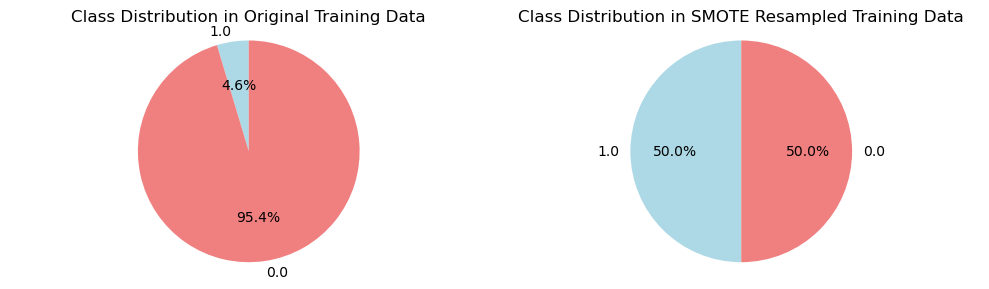

In [54]:
original_class_counts = Counter(y_train)
resampled_class_counts = Counter(y_train_resampled)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].pie(original_class_counts.values(), 
            labels=original_class_counts.keys(), 
            autopct='%1.1f%%', 
            colors=['lightblue', 'lightcoral'], 
            startangle=90)
axes[0].set_title("Class Distribution in Original Training Data")
axes[0].axis('equal')

axes[1].pie(resampled_class_counts.values(), 
            labels=resampled_class_counts.keys(), 
            autopct='%1.1f%%', 
            colors=['lightblue', 'lightcoral'], 
            startangle=90)
axes[1].set_title("Class Distribution in SMOTE Resampled Training Data")
axes[1].axis('equal')  

plt.tight_layout()
plt.show()


In [55]:
# Logistic Regression
log_reg = LogisticRegression(solver='saga', max_iter=2000, random_state=42)
log_reg.fit(X_train_resampled, y_train_resampled)
y_pred_log = log_reg.predict(X_test)
default_probability_log = log_reg.predict_proba(X_test)[:, 1]
print(default_probability_log)
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_log))
log_reg_final = log_reg

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[0.1967565  0.01983717 0.05085233 ... 0.64192756 0.00733742 0.37206719]
Logistic Regression Performance:
              precision    recall  f1-score   support

         0.0       1.00      0.87      0.93    150532
         1.0       0.26      0.96      0.41      7200

    accuracy                           0.88    157732
   macro avg       0.63      0.92      0.67    157732
weighted avg       0.96      0.88      0.91    157732



In [56]:
# XGBoost
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = xgb_model.predict(X_test)
default_probability_xgb = log_reg.predict_proba(X_test)[:, 1]
print(default_probability_xgb)
print("XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))
xgb_model_final = xgb_model

[0.1967565  0.01983717 0.05085233 ... 0.64192756 0.00733742 0.37206719]
XGBoost Performance:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    150532
         1.0       1.00      0.99      0.99      7200

    accuracy                           1.00    157732
   macro avg       1.00      0.99      0.99    157732
weighted avg       1.00      1.00      1.00    157732



In [65]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [125]:
import joblib
from datetime import datetime

In [69]:
joblib.dump(log_reg_final, '/Users/divijakejriwal/lending_platform/ml_models/individual_logistic_model.pkl')
joblib.dump(xgb_model_final, '/Users/divijakejriwal/lending_platform/ml_models/individual_xgboost_model.pkl')

['/Users/divijakejriwal/lending_platform/ml_models/individual_xgboost_model.pkl']

In [137]:
X_train.columns

Index(['months_since_credit_pull', 'policy_code', 'months_since_last_pymnt',
       'initial_list_status', 'term_months', 'recoveries',
       'collection_recovery_fee', 'verification_status_encoded', 'out_prncp',
       'out_prncp_inv', 'grade_ordinal', 'last_pymnt_amnt', 'int_rate',
       'total_rec_prncp', 'member_id', 'inq_last_6mths', 'installment',
       'sub_grade', 'emp_length_encoded', 'total_pymnt', 'addr_state',
       'total_pymnt_inv'],
      dtype='object')

In [127]:
predictions = xgb_model_final.predict_proba(df[selected_features_mutual_info])[:, 1]
df['default_probability'] = predictions
df['last_updated'] = datetime.now()
print(df.columns)

    member_id  loan_amnt  funded_amnt  funded_amnt_inv  int_rate  installment  \
0  12000897.0    27050.0      27050.0          27050.0     10.99       885.46   
1  12011200.0     9750.0       9750.0           9750.0     13.98       333.14   
2   1319523.0    12000.0      12000.0          12000.0      6.62       368.45   
3  11991209.0    12000.0      12000.0          12000.0     13.53       407.40   
4  12011167.0    15000.0      15000.0          15000.0      8.90       476.30   

   sub_grade  annual_inc  addr_state    dti  ...  verification_status_encoded  \
0    43954.0     55000.0     20829.0  22.87  ...                          2.0   
1    47598.0     26000.0    113253.0  25.12  ...                          0.0   
2    19522.0    105000.0     11824.0  14.05  ...                          0.0   
3    42831.0     40000.0      4439.0  16.94  ...                          1.0   
4    39762.0     63000.0     53603.0  16.51  ...                          0.0   

   emp_length_encoded  cre

In [129]:
print(df.columns)

Index(['member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
       'installment', 'sub_grade', 'annual_inc', 'addr_state', 'dti',
       'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_amnt', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'policy_code', 'acc_now_delinq',
       'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'default_ind',
       'grade_ordinal', 'term_months', 'verification_status_encoded',
       'emp_length_encoded', 'credit_history_length',
       'months_since_last_pymnt', 'months_since_credit_pull',
       'Rev_to_Inc_Ratio', 'Loan_Payment_to_Income_Ratio',
       'Repayment_Progress', 'default_probability', 'last_updat

In [133]:
df.rename(columns={
    'term_months': 'term',
    'emp_length_encoded': 'emp_length',
    'verification_status_encoded': 'verification_status',
    'grade_ordinal': 'grade',
}, inplace=True)

In [135]:
df.to_csv('updated_data.csv', index=False)

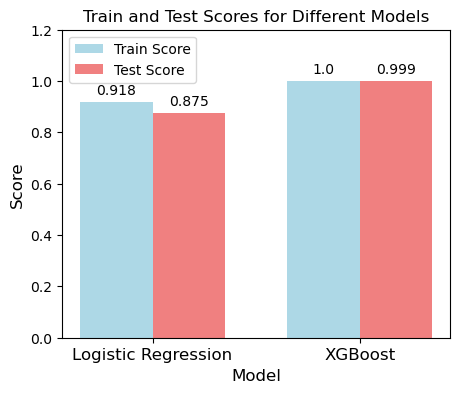

In [107]:
import plotly.graph_objects as go
from sklearn.metrics import accuracy_score

# Train and test scores
log_reg_train_score = log_reg_final.score(X_train_resampled, y_train_resampled)
log_reg_test_score = log_reg_final.score(X_test, y_test)

xgb_train_score = xgb_model_final.score(X_train_resampled, y_train_resampled)
xgb_test_score = xgb_model_final.score(X_test, y_test)

# Create a DataFrame to store the results
df_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Train Score': [log_reg_train_score, xgb_train_score],
    'Test Score': [log_reg_test_score, xgb_test_score]
})

# Plotting with matplotlib
fig, ax = plt.subplots(figsize=(5, 4))  # Increase the figure size to ensure readability

# Plot the Train and Test scores for each model
bar_width = 0.35  # width of the bars
index = range(len(df_results))  # Model index positions

# Plot bars for Train Score and Test Score
train_bars = ax.bar(index, df_results['Train Score'], bar_width, label='Train Score', color='lightblue')
test_bars = ax.bar([i + bar_width for i in index], df_results['Test Score'], bar_width, label='Test Score', color='lightcoral')

# Add labels, title, and customize axis
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Train and Test Scores for Different Models', fontsize=12)
ax.set_xticks([i + bar_width / 2 for i in index])  # Position the x-axis ticks in the middle of the bars
ax.set_xticklabels(df_results['Model'], fontsize=12)
ax.legend()
ax.set_ylim(0, 1.2)

# Add value labels on top of the bars
for bar in train_bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, round(yval, 3), ha='center', va='bottom', fontsize=10)

for bar in test_bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, round(yval, 3), ha='center', va='bottom', fontsize=10)

# Show plot
plt.show()

In [109]:
def plotting_confusion_matrix(y_test, y_predict_log, y_predict_xgb):
    
    # Confusion Matrix for both models
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    
    # Logistic Regression Confusion Matrix
    cm_log = confusion_matrix(y_test, y_pred_log)
    sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'], ax=ax[0])
    ax[0].set_title('Logistic Regression Confusion Matrix')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')
    
    # XGBoost Confusion Matrix
    cm_xgb = confusion_matrix(y_test, y_pred_xgb)
    sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'], ax=ax[1])
    ax[1].set_title('XGBoost Confusion Matrix')
    ax[1].set_xlabel('Predicted')
    ax[1].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()

Balanced and Fine-Tuned Model


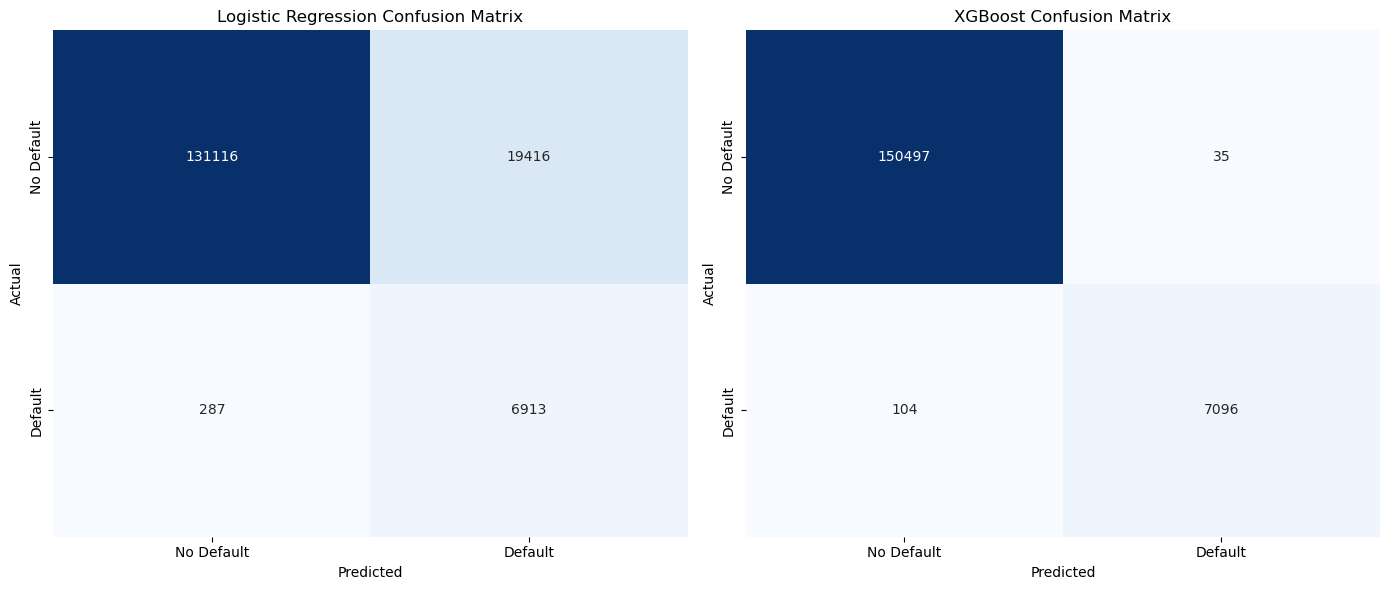

In [111]:
print("Balanced and Fine-Tuned Model")
plotting_confusion_matrix(y_test, y_pred_log, y_pred_xgb)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



Logistic Regression Performance:
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.98    150532
         1.0       0.93      0.00      0.00      7200

    accuracy                           0.95    157732
   macro avg       0.94      0.50      0.49    157732
weighted avg       0.95      0.95      0.93    157732

XGBoost Performance:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    150532
         1.0       1.00      0.99      0.99      7200

    accuracy                           1.00    157732
   macro avg       1.00      0.99      1.00    157732
weighted avg       1.00      1.00      1.00    157732

Unbalanced and Fine-Tuned Model


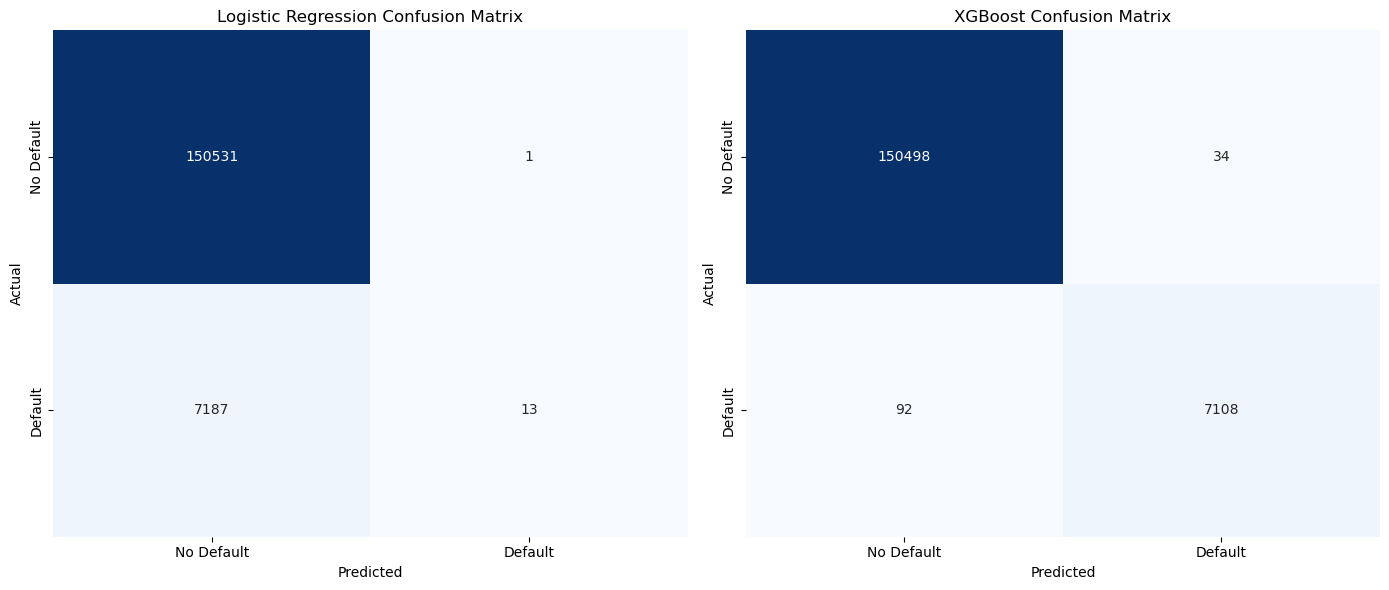

In [113]:
# Unbalanced data 

# Logistic Regression
log_reg = LogisticRegression(solver='saga', max_iter=4000, C=1, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_log))

# XGBoost
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))

print("Unbalanced and Fine-Tuned Model")
plotting_confusion_matrix(y_test, y_pred_log, y_pred_xgb)

In [ ]:
'''

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(

for iterations=2000
'''

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



Logistic Regression Performance:
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.98    150532
         1.0       0.80      0.00      0.00      7200

    accuracy                           0.95    157732
   macro avg       0.88      0.50      0.49    157732
weighted avg       0.95      0.95      0.93    157732

XGBoost Performance:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    150532
         1.0       1.00      0.97      0.98      7200

    accuracy                           1.00    157732
   macro avg       1.00      0.99      0.99    157732
weighted avg       1.00      1.00      1.00    157732

Basic Model


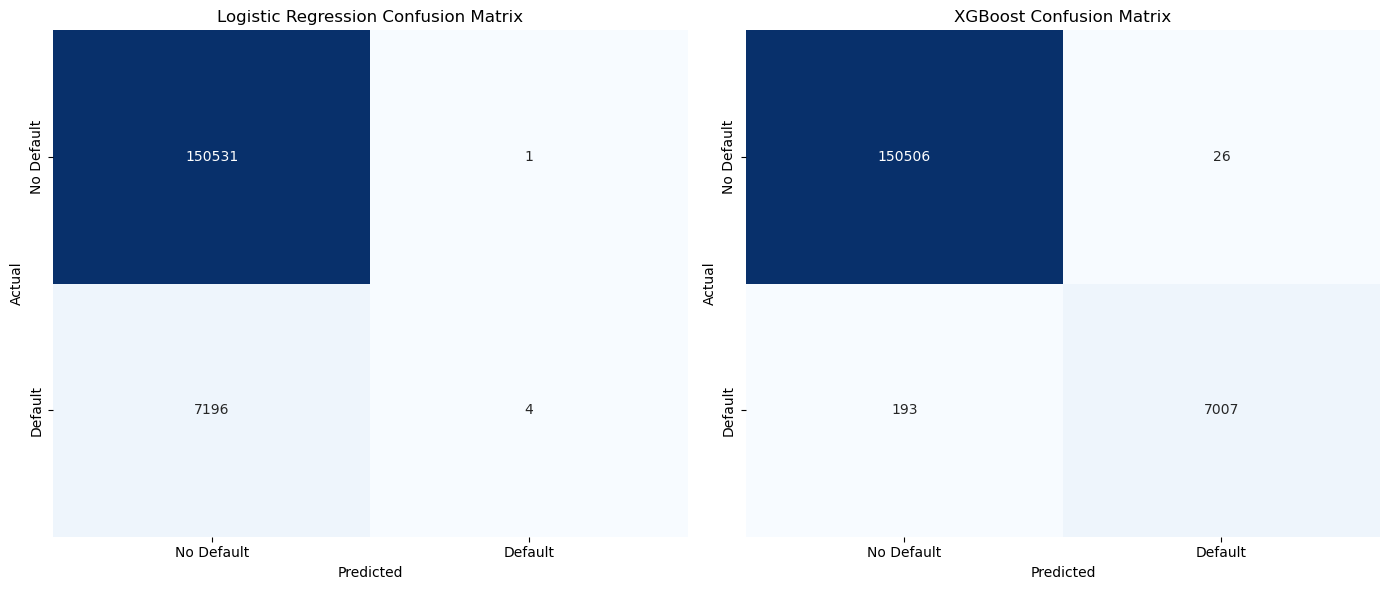

In [115]:
# Without user transformed data - Base
X = X.drop(columns=['Rev_to_Inc_Ratio', 'Loan_Payment_to_Income_Ratio', 'Repayment_Progress'],axis=1, errors='ignore')
y = y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
log_reg = LogisticRegression(solver='saga', max_iter=2000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_log))

# XGBoost
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb))

print("Basic Model")
plotting_confusion_matrix(y_test, y_pred_log, y_pred_xgb)